In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.surf_score import calculate_surf_score

In [2]:
df = pd.read_csv("../data/raw/marine_data.csv")

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name
0,2026-08-23T00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora
1,2026-08-23T01:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora
2,2026-08-23T02:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora
3,2026-08-23T03:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora
4,2026-08-23T04:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (720, 12)

Columns:
['time', 'wave_height', 'wave_period', 'wave_direction', 'wind_wave_height', 'swell_wave_height', 'swell_wave_period', 'swell_wave_direction', 'wind_speed_10m', 'wind_direction_10m', 'beach_id', 'beach_name']


In [4]:
df.isnull().sum()

time                    0
wave_height             0
wave_period             0
wave_direction          0
wind_wave_height        0
swell_wave_height       0
swell_wave_period       0
swell_wave_direction    0
wind_speed_10m          0
wind_direction_10m      0
beach_id                0
beach_name              0
dtype: int64

In [5]:
df["time"] = pd.to_datetime(df["time"])

df.dtypes

time                    datetime64[us]
wave_height                    float64
wave_period                    float64
wave_direction                   int64
wind_wave_height               float64
swell_wave_height              float64
swell_wave_period              float64
swell_wave_direction             int64
wind_speed_10m                 float64
wind_direction_10m               int64
beach_id                         int64
beach_name                         str
dtype: object

In [6]:
beaches = pd.read_csv("../data/beaches.csv")

beaches = beaches.rename(columns={"id": "beach_id"})

beaches.head()

,beach_id,name,country,latitude,longitude,preferred_swell_direction_deg,swell_direction_tolerance_deg,preferred_wind_direction_deg,wind_direction_tolerance_deg
0,1,Máncora,Peru,-4.1078,-81.0475,315,45,112,45
1,2,Lobitos,Peru,-4.4553,-81.2808,225,45,112,45
2,3,Chicama,Peru,-7.8440,-79.1465,225,45,135,45
3,4,Huanchaco,Peru,-8.0810,-79.1200,180,90,157,45
4,5,Pacasmayo,Peru,-7.4015,-79.5710,225,45,45,45


In [7]:
df = df.merge(
    beaches[
        [
            "beach_id",
            "preferred_swell_direction_deg",
            "swell_direction_tolerance_deg",
            "preferred_wind_direction_deg",
            "wind_direction_tolerance_deg"
        ]
    ],
    on="beach_id",
    how="left"
)

df.head()

,time,wave_height,wave_period,wave_direction,wind_wave_height,swell_wave_height,swell_wave_period,swell_wave_direction,wind_speed_10m,wind_direction_10m,beach_id,beach_name,preferred_swell_direction_deg,swell_direction_tolerance_deg,preferred_wind_direction_deg,wind_direction_tolerance_deg
0,2026-08-23 00:00:00,0.92,7.90,224,0.38,0.46,9.70,227,7.9,177,1,Máncora,315,45,112,45
1,2026-08-23 01:00:00,0.88,8.05,225,0.36,0.46,10.05,227,9.3,188,1,Máncora,315,45,112,45
2,2026-08-23 02:00:00,0.88,8.05,224,0.40,0.46,10.10,227,10.5,192,1,Máncora,315,45,112,45
3,2026-08-23 03:00:00,0.88,8.00,223,0.42,0.44,10.00,227,11.9,185,1,Máncora,315,45,112,45
4,2026-08-23 04:00:00,0.88,7.95,222,0.46,0.44,9.90,227,13.6,186,1,Máncora,315,45,112,45


In [8]:
beach_summary = (
    df.groupby("beach_name")
    .agg(
        avg_wave_height=("wave_height", "mean"),
        max_wave_height=("wave_height", "max"),
        avg_wave_period=("wave_period", "mean"),
        max_wave_period=("wave_period", "max")
    )
    .round(2)
)

beach_summary

,avg_wave_height,max_wave_height,avg_wave_period,max_wave_period
beach_name,,,,
Cerro Azul,1.08,1.28,10.23,11.15
Chicama,0.91,1.00,9.88,10.75
Huanchaco,1.03,1.12,10.11,10.80
Lobitos,1.06,1.18,8.12,9.55
Máncora,0.96,1.16,7.59,10.15
Pacasmayo,0.90,1.04,8.32,9.25
Punta Hermosa,1.04,1.16,10.45,11.05
Punta Rocas,1.03,1.16,10.60,11.10
Punta Roquitas,1.17,1.30,9.93,10.45


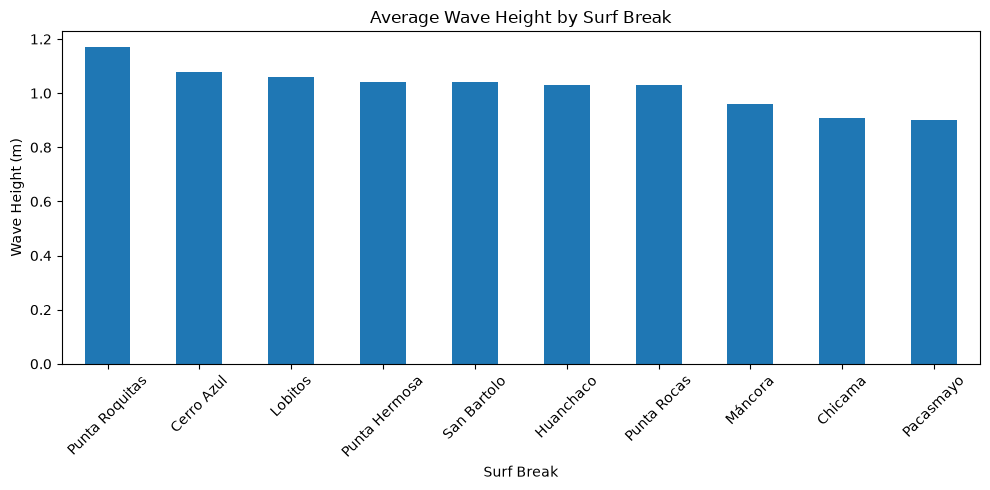

In [9]:
beach_summary["avg_wave_height"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Wave Height by Surf Break",
    ylabel="Wave Height (m)",
    xlabel="Surf Break"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df["surf_score"] = df.apply(
    lambda row: calculate_surf_score(
        wave_height=row["wave_height"],
        wave_period=row["wave_period"],
        wind_speed=row["wind_speed_10m"],
        wave_direction=row["wave_direction"],
        preferred_swell_direction=row["preferred_swell_direction_deg"],
        wind_direction=row["wind_direction_10m"],
        preferred_wind_direction=row["preferred_wind_direction_deg"]
    ),
    axis=1
)

df[
    [
        "time",
        "beach_name",
        "wave_height",
        "wave_period",
        "wind_speed_10m",
        "wind_direction_10m",
        "surf_score"
    ]
].head(10)

,time,beach_name,wave_height,wave_period,wind_speed_10m,wind_direction_10m,surf_score
0,2026-08-23 00:00:00,Máncora,0.92,7.90,7.9,177,43.3
1,2026-08-23 01:00:00,Máncora,0.88,8.05,9.3,188,48.4
2,2026-08-23 02:00:00,Máncora,0.88,8.05,10.5,192,44.5
3,2026-08-23 03:00:00,Máncora,0.88,8.00,11.9,185,46.0
4,2026-08-23 04:00:00,Máncora,0.88,7.95,13.6,186,38.3
5,2026-08-23 05:00:00,Máncora,0.88,7.90,14.5,186,38.3
6,2026-08-23 06:00:00,Máncora,0.90,7.90,16.6,186,34.6
7,2026-08-23 07:00:00,Máncora,0.90,7.85,21.8,182,32.4
8,2026-08-23 08:00:00,Máncora,0.92,7.85,21.4,173,34.4
9,2026-08-23 09:00:00,Máncora,0.92,7.85,18.9,176,36.8


In [11]:
beach_scores = (
    df.groupby("beach_name")
    .agg(
        avg_surf_score=("surf_score", "mean"),
        max_surf_score=("surf_score", "max"),
        min_surf_score=("surf_score", "min")
    )
    .round(1)
    .sort_values("avg_surf_score", ascending=False)
)

beach_scores

,avg_surf_score,max_surf_score,min_surf_score
beach_name,,,
Huanchaco,74.3,85.7,65.7
Punta Rocas,67.9,85.5,54.8
Punta Hermosa,66.2,87.8,54.2
Cerro Azul,64.8,82.1,55.0
San Bartolo,62.7,79.5,54.2
Chicama,62.3,80.1,51.6
Punta Roquitas,61.0,71.3,53.2
Lobitos,53.1,62.7,42.3
Pacasmayo,45.1,52.8,34.8


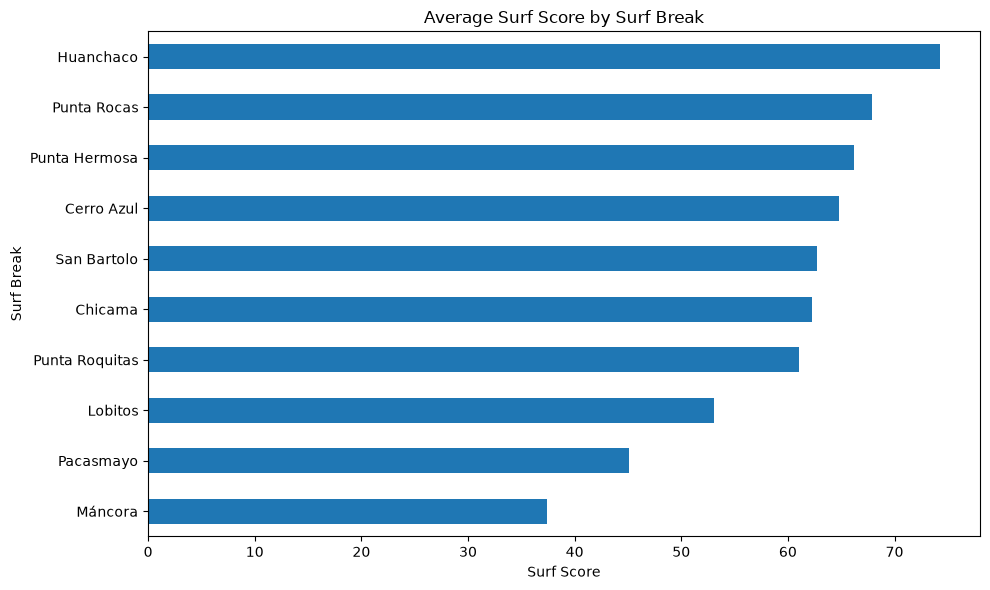

In [12]:
beach_scores["avg_surf_score"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 6),
    title="Average Surf Score by Surf Break",
    xlabel="Surf Score",
    ylabel="Surf Break"
)

plt.tight_layout()
plt.show()

In [13]:
def show_beach_forecast(beach_name):
    beach = df[df["beach_name"] == beach_name].copy()

    print(f"Surf Forecast: {beach_name}")
    print(f"Average Surf Score: {beach['surf_score'].mean():.1f}")
    print(f"Best Surf Score: {beach['surf_score'].max():.1f}")

    beach.plot(
        x="time",
        y="surf_score",
        kind="line",
        figsize=(12, 5),
        title=f"Surf Score - {beach_name} - 72 Hour Forecast",
        xlabel="Time",
        ylabel="Surf Score"
    )

    plt.tight_layout()
    plt.show()

Surf Forecast: Punta Rocas
Average Surf Score: 67.9
Best Surf Score: 85.5


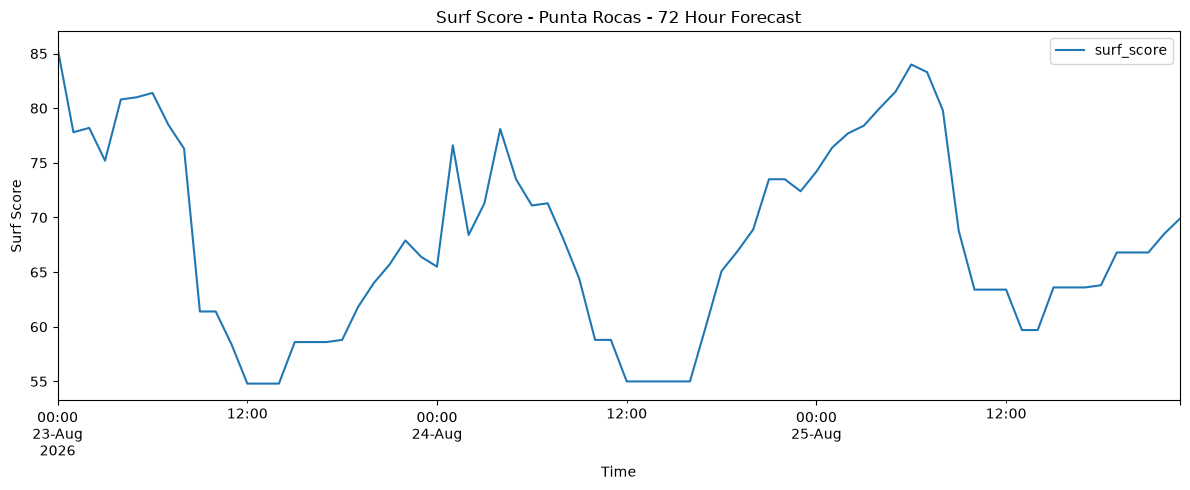

In [14]:
show_beach_forecast("Punta Rocas")

In [15]:
def best_surf_times(beach_name, n=5):
    beach = df[df["beach_name"] == beach_name].copy()

    best = (
        beach[
            [
                "time",
                "surf_score",
                "wave_height",
                "wave_period",
                "wave_direction",
                "wind_speed_10m",
                "wind_direction_10m"
            ]
        ]
        .sort_values("surf_score", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    return best

In [16]:
best_surf_times("Punta Rocas")

,time,surf_score,wave_height,wave_period,wave_direction,wind_speed_10m,wind_direction_10m
0,2026-08-23 00:00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-25 06:00:00,84.0,1.12,10.05,202,5.7,101
2,2026-08-25 07:00:00,83.3,1.14,10.05,202,6.9,104
3,2026-08-25 05:00:00,81.5,1.12,10.05,202,6.4,112
4,2026-08-23 06:00:00,81.4,0.98,10.70,202,5.0,90


In [17]:
def show_beach_conditions(beach_name):
    beach = df[df["beach_name"] == beach_name].copy()

    conditions = beach[
        [
            "time",
            "surf_score",
            "wave_height",
            "wave_period",
            "wave_direction",
            "wind_speed_10m",
            "wind_direction_10m"
        ]
    ].copy()

    conditions = conditions.rename(
        columns={
            "time": "Time",
            "surf_score": "Surf Score",
            "wave_height": "Wave Height (m)",
            "wave_period": "Wave Period (s)",
            "wave_direction": "Swell Direction (°)",
            "wind_speed_10m": "Wind Speed (km/h)",
            "wind_direction_10m": "Wind Direction (°)"
        }
    )

    return conditions.reset_index(drop=True)

In [18]:
show_beach_conditions("Punta Rocas")

,Time,Surf Score,Wave Height (m),Wave Period (s),Swell Direction (°),Wind Speed (km/h),Wind Direction (°)
0,2026-08-23 00:00:00,85.5,1.02,10.60,202,3.7,104
1,2026-08-23 01:00:00,77.8,1.00,10.65,202,8.6,129
2,2026-08-23 02:00:00,78.2,1.00,10.70,202,7.8,127
3,2026-08-23 03:00:00,75.2,0.98,10.70,202,6.9,118
4,2026-08-23 04:00:00,80.8,0.98,10.70,202,6.0,87
...,...,...,...,...,...,...,...
67,2026-08-25 19:00:00,66.8,1.14,10.35,204,9.6,189
68,2026-08-25 20:00:00,66.8,1.14,10.40,204,8.3,184
69,2026-08-25 21:00:00,66.8,1.12,10.45,204,7.2,180
70,2026-08-25 22:00:00,68.5,1.12,10.45,204,8.0,172
